# Exploratory Data Analysis (EDA): In-Depth E-Commerce Data Understanding

## 1. Objective
Before applying any Machine Learning model (Regression, Classification, or Clustering), we must thoroughly understand our 1.42M rows of e-commerce data. 
In this notebook, we will investigate:
- Dataset dimensions and memory usage.
- Missing value percentages per column.
- Statistical distributions of financial metrics (`grand_total`, `sub_total`, etc.).
- Cardinality and distribution of categorical variables (`status`, `channel_name`, etc.).
- Temporal trends (`created_at`).

# Import Libraries 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Read data 

In [2]:
df=pd.read_csv("data.csv")
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_20408\4079643837.py:1: DtypeWarning: Columns (0: coupon_code, 1: additional) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("data.csv")


,id,old_order_id,increment_id,status,channel_name,is_guest,customer_email,customer_first_name,customer_last_name,shipping_method,...,additional,tabby_payment_id,tabby_order_status,paymob_intention_id,paymob_cents_amount,tamara_order_id,tamara_checkout_id,cko_hpp_id,cko_payment_id,cko_session_id
0,1,NaN,ORD-00000001,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,ORD-00000002,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,ORD-00000003,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,ORD-00000004,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,ORD-00000005,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Explore the data 

In [3]:
df.shape

(146201, 85)

In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 146201 entries, 0 to 146200
Data columns (total 85 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             146201 non-null  int64  
 1   old_order_id                   23913 non-null   float64
 2   increment_id                   146201 non-null  str    
 3   status                         146201 non-null  str    
 4   channel_name                   146201 non-null  str    
 5   is_guest                       146201 non-null  int64  
 6   customer_email                 134010 non-null  str    
 7   customer_first_name            136057 non-null  str    
 8   customer_last_name             74428 non-null   str    
 9   shipping_method                75149 non-null   str    
 10  shipping_title                 75149 non-null   str    
 11  shipping_description           75149 non-null   str    
 12  coupon_code                    13444 non-

In [7]:
df.describe().value_counts()

id        old_order_id  is_guest  is_gift   total_item_count  total_qty_ordered  grand_total  cashback_opt_in  cashback_earned  base_grand_total  vas_total  grand_total_invoiced  base_grand_total_invoiced  grand_total_refunded  base_grand_total_refunded  sub_total  base_sub_total  sub_total_invoiced  base_sub_total_invoiced  sub_total_refunded  base_sub_total_refunded  wallet_credit_used  discount_percent  discount_amount  base_discount_amount  discount_invoiced  base_discount_invoiced  discount_refunded  base_discount_refunded  tax_amount  base_tax_amount  tax_amount_invoiced  base_tax_amount_invoiced  tax_amount_refunded  base_tax_amount_refunded  shipping_amount  base_shipping_amount  shipping_invoiced  base_shipping_invoiced  shipping_refunded  base_shipping_refunded  shipping_discount_amount  base_shipping_discount_amount  shipping_tax_amount  base_shipping_tax_amount  shipping_tax_refunded  base_shipping_tax_refunded  sub_total_incl_tax  base_sub_total_incl_tax  shipping_amount_i

In [8]:
print(df.isnull().sum())


id                                    0
old_order_id                     122288
increment_id                          0
status                                0
channel_name                          0
is_guest                              0
customer_email                    12191
customer_first_name               10144
customer_last_name                71773
shipping_method                   71052
shipping_title                    71052
shipping_description              71052
coupon_code                      132757
is_gift                               0
total_item_count                      0
total_qty_ordered                     0
base_currency_code                    0
channel_currency_code                 0
order_currency_code                   0
grand_total                           0
cashback_opt_in                       0
cashback_earned                       0
base_grand_total                      0
vas_total                             0
grand_total_invoiced                  0


In [9]:
# Percentage of missing values per column
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)


id                                 0.000000
old_order_id                      83.643751
increment_id                       0.000000
status                             0.000000
channel_name                       0.000000
is_guest                           0.000000
customer_email                     8.338520
customer_first_name                6.938393
customer_last_name                49.092003
shipping_method                   48.598847
shipping_title                    48.598847
shipping_description              48.598847
coupon_code                       90.804440
is_gift                            0.000000
total_item_count                   0.000000
total_qty_ordered                  0.000000
base_currency_code                 0.000000
channel_currency_code              0.000000
order_currency_code                0.000000
grand_total                        0.000000
cashback_opt_in                    0.000000
cashback_earned                    0.000000
base_grand_total                

In [11]:
df["shipping_method"].value_counts(normalize=True)

shipping_method
flatrate_flatrate    0.999627
free_free            0.000373
Name: proportion, dtype: float64

In [21]:
df["shipping_description"].value_counts(normalize=True)

shipping_description
Shipping Fee          0.797083
Flat Rate Shipping    0.202544
Free Shipping         0.000373
Name: proportion, dtype: float64

In [35]:
# Drop columns with more than 50% missing values
df = df.dropna(thresh=len(df) * 0.5, axis=1)

In [42]:
df = df.drop(columns=["shipping_method", "shipping_description", 
                      "shipping_title", "additional","customer_last_name","cart_id",
                      "customer_email","customer_first_name"], errors="ignore")


In [43]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

id                               0.0
increment_id                     0.0
status                           0.0
channel_name                     0.0
is_guest                         0.0
is_gift                          0.0
total_item_count                 0.0
total_qty_ordered                0.0
base_currency_code               0.0
channel_currency_code            0.0
order_currency_code              0.0
grand_total                      0.0
cashback_opt_in                  0.0
cashback_earned                  0.0
base_grand_total                 0.0
vas_total                        0.0
grand_total_invoiced             0.0
base_grand_total_invoiced        0.0
grand_total_refunded             0.0
base_grand_total_refunded        0.0
sub_total                        0.0
base_sub_total                   0.0
sub_total_invoiced               0.0
base_sub_total_invoiced          0.0
sub_total_refunded               0.0
base_sub_total_refunded          0.0
wallet_credit_used               0.0
d

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 146201 entries, 0 to 146200
Data columns (total 64 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             146201 non-null  int64  
 1   increment_id                   146201 non-null  str    
 2   status                         146201 non-null  str    
 3   channel_name                   146201 non-null  str    
 4   is_guest                       146201 non-null  int64  
 5   is_gift                        146201 non-null  int64  
 6   total_item_count               146201 non-null  int64  
 7   total_qty_ordered              146201 non-null  int64  
 8   base_currency_code             146201 non-null  str    
 9   channel_currency_code          146201 non-null  str    
 10  order_currency_code            146201 non-null  str    
 11  grand_total                    146201 non-null  float64
 12  cashback_opt_in                146201 non

### ==========================================
###  Categorical Analysis
### ==========================================

 ORDER STATUS DISTRIBUTION 


status
pending_payment          91601
completed                46226
canceled                  6534
packed                     732
closed                     542
RTO                        287
shipped                    141
processing                  80
pending                     53
pending_payment_proof        4
finance_review               1
Name: count, dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_20408\3472312732.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='status', order=status_counts.index, palette='viridis')


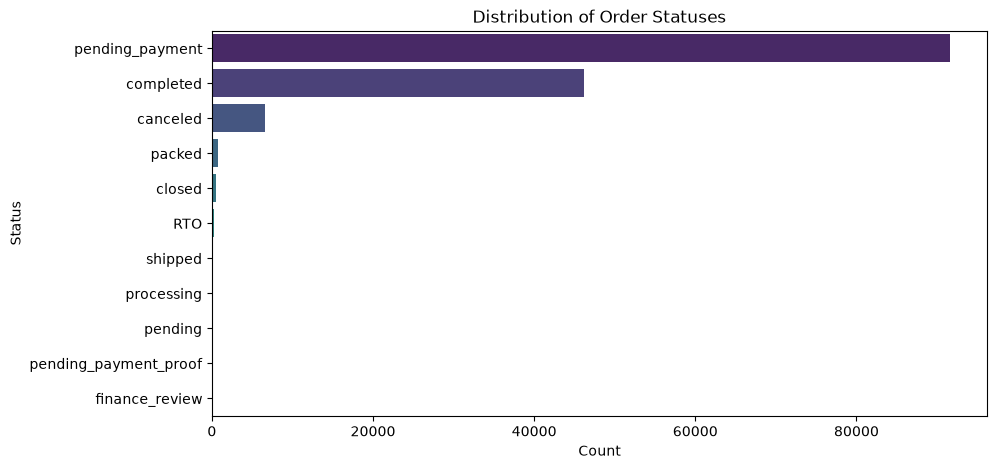


 CHANNEL NAME DISTRIBUTION 


channel_name
Cartlow UAE              87521
Cartlow KSA              34341
Cartlow International    24036
South Africa               280
Cartlow B2B                 23
Name: count, dtype: int64

In [48]:


print(" ORDER STATUS DISTRIBUTION ")
if 'status' in df.columns:
    status_counts = df['status'].value_counts()
    display(status_counts)
    
    # Quick visualization of order status
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, y='status', order=status_counts.index, palette='viridis')
    plt.title('Distribution of Order Statuses')
    plt.xlabel('Count')
    plt.ylabel('Status')
    plt.show()

print("\n" + "=" * 50)
print(" CHANNEL NAME DISTRIBUTION ")
print("=" * 50)
if 'channel_name' in df.columns:
    display(df['channel_name'].value_counts())

### =====================
### Temporal Analysis
### =====================

Dataset Date Range:
Start Date: 2022-12-24 12:40:45
End Date: 2026-08-18 13:28:35


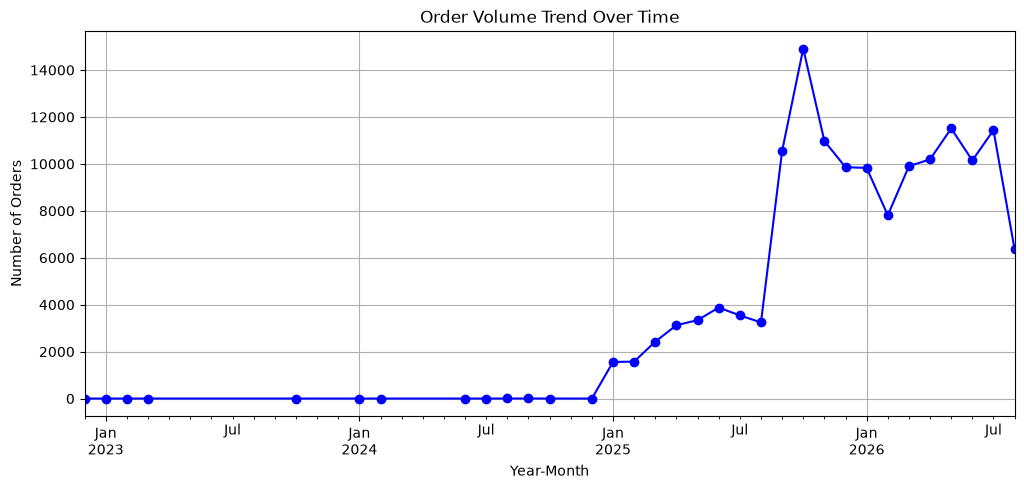

In [49]:

if 'created_at' in df.columns:
    df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce')
    print("Dataset Date Range:")
    print(f"Start Date: {df['created_at_dt'].min()}")
    print(f"End Date: {df['created_at_dt'].max()}")
    
    # Orders per year/month trend
    df['year_month'] = df['created_at_dt'].dt.to_period('M')
    plt.figure(figsize=(12, 5))
    df['year_month'].value_counts().sort_index().plot(kind='line', marker='o', color='b')
    plt.title('Order Volume Trend Over Time')
    plt.xlabel('Year-Month')
    plt.ylabel('Number of Orders')
    plt.grid(True)
    plt.show()

In [52]:
# Loop through only string (object) columns
for col in df.select_dtypes(include="object").columns:
    print(f"Column: {col}")
    print(df[col].unique())   # unique values in that column
    print("-" * 40)


Column: increment_id
<ArrowStringArray>
[  'ORD-00000001',   'ORD-00000002',   'ORD-00000003',   'ORD-00000004',
   'ORD-00000005',   'ORD-00000006',   'ORD-00000007',   'ORD-00000008',
   'ORD-00000009',   'ORD-00000010',
 ...
 'ORD-1003298513', 'ORD-1003298514', 'ORD-1003298515', 'ORD-1003298516',
 'ORD-1003298517', 'ORD-1003298518', 'ORD-1003298519', 'ORD-1003298520',
 'ORD-1003298521', 'ORD-1003298522']
Length: 146201, dtype: str
----------------------------------------
Column: status
<ArrowStringArray>
[               'closed',       'pending_payment',              'canceled',
               'pending',             'completed',                'packed',
            'processing',               'shipped',                   'RTO',
        'finance_review', 'pending_payment_proof']
Length: 11, dtype: str
----------------------------------------
Column: channel_name
<ArrowStringArray>
[          'Cartlow UAE',           'Cartlow KSA', 'Cartlow International',
          'South Africa',   

C:\Users\hp\AppData\Local\Temp\ipykernel_20408\3768239579.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


# ==========================================
# Safe Encoding with Cardinality Check
# ==========================================

In [57]:

print("Checking unique values per categorical column:")
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    unique_count = df_cleaned[col].nunique()
    print(f"Column '{col}': {unique_count} unique values")
    
    if unique_count > 100:
        print(f"--> Dropping '{col}' because it has too many unique values (causes memory error!)")
        df_cleaned = df_cleaned.drop(columns=[col])
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

print("\nEncoding successfully completed without memory crash!")
print(f"New encoded shape: {df_encoded.shape}")

Checking unique values per categorical column:
Column 'status': 11 unique values
Column 'channel_name': 5 unique values
Column 'base_currency_code': 4 unique values
Column 'channel_currency_code': 4 unique values
Column 'order_currency_code': 4 unique values
Column 'customer_type': 1 unique values
Column 'channel_type': 1 unique values

Encoding successfully completed without memory crash!
New encoded shape: (146201, 81)


C:\Users\hp\AppData\Local\Temp\ipykernel_20408\4180642566.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 146201 entries, 0 to 146200
Data columns (total 66 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   id                             146201 non-null  int64         
 1   increment_id                   146201 non-null  str           
 2   status                         146201 non-null  str           
 3   channel_name                   146201 non-null  str           
 4   is_guest                       146201 non-null  int64         
 5   is_gift                        146201 non-null  int64         
 6   total_item_count               146201 non-null  int64         
 7   total_qty_ordered              146201 non-null  int64         
 8   base_currency_code             146201 non-null  str           
 9   channel_currency_code          146201 non-null  str           
 10  order_currency_code            146201 non-null  str           
 11  grand_total